# Notebook 12 — Lean Quantile Models: V1 vs V2 Cleaning Comparison

**Objective:** Isolate the effect of the improved outlier removal on model performance.

| | V1 | V2 |
|---|---|---|
| **Data cleaning** | Brand-only IQR (original `clean_car_data`) | Brand+year IQR (`CarDataProcessor` updated) |
| **Features** | Lean: brand/model/year stats only | **Identical** to V1 |
| **Hyperparameters** | `lr=0.1`, `n=5000` | **Identical** to V1 |
| **Feature engineer** | `brand_onehot=False`, `model_onehot=False` | **Identical** to V1 |

**V1** is the pre-trained production model from NB06, trained on 100% of October data (brand-only IQR cleaning).  
**V2** is retrained here on 100% of October data using the updated brand+year IQR cleaning.  
**Both are evaluated on the December 2025 extraction — a genuinely held-out test set neither model has seen.**

**Sections:**
1. Setup & Constants
2. Load October Raw Data
3. V1 — Load Pre-trained Pipeline (NB06 production)
4. V2 — Clean October Data with Brand+Year IQR
5. V2 — Feature Engineering & Train on Full October Data
6. Load & Clean December Data (Held-Out Test Set)
7. Evaluate Both Models on December Data
8. Median APE by Calendar Year
9. Median APE by Age Bucket
10. Coverage by Year
11. Save V2 Models
12. MLflow Logging
13. Summary

## 1. Setup & Constants

In [ ]:
import os
import sys
import json
import importlib
import joblib
from datetime import datetime
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from lightgbm import LGBMRegressor
import mlflow
import mlflow.lightgbm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Project root
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / 'src'))

import data_processing
import features.feature_engineering as _fe_module
importlib.reload(_fe_module)
from features.feature_engineering import CarPriceFeatureEngineer
from data_processing import CarDataProcessor
from config import DATA_PATH

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

# ── Constants ────────────────────────────────────────────────────────────────
CURRENT_YEAR    = 2025
TRAIN_TEST_SEED = 42
MLFLOW_URI      = f"file://{project_root / 'mlruns'}"

# ── Paths ─────────────────────────────────────────────────────────────────────
oct_data_dir = Path(os.path.join(DATA_PATH, 'le_boncoin_13_oct_2025'))
dec_data_dir = Path(os.path.join(DATA_PATH, 'le_boncoin_16_dec_2025'))
v1_dir       = project_root / 'models' / 'lean_quantile'
v2_dir       = project_root / 'models' / 'lean_quantile_v2_lean'
output_dir   = project_root / 'output'

# ── Shared lean feature set (identical to NB06 production model) ──────────────
# 31 features: brand/model/year aggregates only — no km, no fuel type, no HP
LEAN_FEATURES = [
    'car_age',
    'brand_avg_age',       'brand_median_age',
    'brand_mean_log_price','brand_median_log_price','brand_std_log_price',
    'model_count',         'model_popularity_ratio',
    'model_mean_log_price','model_median_log_price','model_std_log_price',
    'is_almost_new',       'decade',
    'sqrt_age',            'age_squared',           'age_cubed',
    'brand_top25_price',   'brand_bottom25_price',  'brand_top5_price',
    'model_top25_price',   'model_bottom25_price',  'model_top5_price',
    'model_rank_within_brand',
    'brand_p25_log_price', 'brand_p75_log_price',   'brand_p90_log_price', 'brand_iqr_log_price',
    'model_p25_log_price', 'model_p75_log_price',   'model_p90_log_price', 'model_iqr_log_price',
]

# ── LightGBM hyperparameters (identical to NB06) ─────────────────────────────
LGB_PARAMS = dict(
    objective   = 'quantile',
    learning_rate = 0.1,
    n_estimators  = 5000,
    random_state  = TRAIN_TEST_SEED,
    verbose       = -1,
)

print(f'Project root : {project_root}')
print(f'October data : {oct_data_dir}')
print(f'December data: {dec_data_dir}')
print(f'V1 models    : {v1_dir}')
print(f'V2 models    : {v2_dir}')
print(f'MLflow store : {MLFLOW_URI}')
print(f'Lean features: {len(LEAN_FEATURES)}')
print('✓ Setup complete')

Project root : /Users/brunobrumbrum/car_price_prediction
October data : /Users/brunobrumbrum/Documents/data/car_price_prediction/le_boncoin_13_oct_2025
V1 models    : /Users/brunobrumbrum/car_price_prediction/models/lean_quantile
V2 models    : /Users/brunobrumbrum/car_price_prediction/models/lean_quantile_v2_lean
MLflow store : file:///Users/brunobrumbrum/car_price_prediction/mlruns
Lean features: 31
✓ Setup complete


## 2. Load October Raw Data

In [3]:
df_raw = data_processing.load_car_data(oct_data_dir)
print(f'Raw October rows: {len(df_raw):,}')

📊 Parsing horsepower from puissance_din column...
✅ Loaded 732,427 rows with horsepower parsed
   Note: 'energie' column contains fuel type (kept as-is)
(732427, 36)
Raw October rows: 732,427


## 3. V1 — Load Pre-trained Pipeline (NB06 production)

V1 models were trained in NB06 on 100% of October data cleaned with the **original brand-only IQR**.  
We load the saved artifacts directly — no retraining.

In [4]:
# Load V1 feature engineer and models
fe_v1 = joblib.load(v1_dir / 'feature_engineer_lean.pkl')
models_v1 = {
    'q15': joblib.load(v1_dir / 'lgb_q15_lean.pkl'),
    'q50': joblib.load(v1_dir / 'lgb_q50_lean.pkl'),
    'q85': joblib.load(v1_dir / 'lgb_q85_lean.pkl'),
}

with open(v1_dir / 'metadata.json') as f:
    meta_v1 = json.load(f)

# V1 feature list — read from disk to guarantee exact match with saved models
feat_cols_v1 = (v1_dir / 'feature_list.txt').read_text().strip().splitlines()

print(f'V1 training date  : {meta_v1["training_date"]}')
print(f'V1 training samples: {meta_v1["n_samples"]:,}')
print(f'V1 features        : {len(feat_cols_v1)}')
print(f'V1 known brands    : {len(fe_v1.brand_price_stats_)}')
print(f'V1 known models    : {len(fe_v1.model_price_stats_)}')
print(f'\n✓ V1 pipeline loaded')

# Confirm feature list match
mismatch = set(feat_cols_v1) ^ set(LEAN_FEATURES)
if mismatch:
    print(f'⚠️  Feature list mismatch: {mismatch}')
else:
    print(f'✓ V1 feature list matches LEAN_FEATURES exactly ({len(feat_cols_v1)} cols)')

V1 training date  : 2026-03-13
V1 training samples: 620,918
V1 features        : 31
V1 known brands    : 43
V1 known models    : 805

✓ V1 pipeline loaded
✓ V1 feature list matches LEAN_FEATURES exactly (31 cols)


## 4. V2 — Clean October Data with Brand+Year IQR

Same October raw data, cleaned with the **updated** `CarDataProcessor` that groups IQR by `(brand, year_bucket)`.  
Old cars are now compared against other old cars of the same brand, preventing over-removal of pre-2008 listings.

In [5]:
proc_v2 = CarDataProcessor(
    large_group_threshold=50,
    min_group_size=10,
    verbose=True,
)
df_v2 = proc_v2.clean_data(df_raw)
df_v2 = df_v2.with_columns(pl.col('price').log().alias('log_price'))

stats = proc_v2.cleaning_stats.get('outlier_removal', {})
print(f'\n━━━ V2 cleaning summary (brand+year IQR) ━━━')
print(f"  Rows before IQR   : {stats.get('rows_before', '?'):,}")
print(f"  Removed by IQR    : {stats.get('n_dropped_iqr', '?'):,}")
print(f"  Removed (tiny gr.): {stats.get('n_dropped_small_groups', '?'):,}")
print(f"  Rows after        : {stats.get('rows_after', '?'):,}")
print(f'\nV2 final dataset : {len(df_v2):,} rows')
print(f'Year range       : {df_v2["year"].min()} – {df_v2["year"].max()}')
print(f'Unique brands    : {df_v2["brand"].n_unique()}')
print(f'Unique models    : {df_v2["model"].n_unique()}')

🧹 Starting data cleaning pipeline...

1️⃣ Converting data types and normalizing text...
   Original: 732,427 rows
   After conversion: 732,426 rows
   Removed (invalid price): 1
   Unique brands: 145, Unique models: 1646

2️⃣ Removing antique cars (pre-1990)...
   Removed 14,536 antique cars

3️⃣ Removing 'autre' entries...
   Removed 4,347 'autre' entries

4️⃣ Cleaning horsepower...
   HP cleaning: dropped 5620 cars <50HP, 114 cars >1000HP, 35437 outliers (IQR per brand), 0 missing HP
   Remaining dataset - Mean HP: 139.7, Median HP: 125.0

5️⃣ Dropping rare brands (<400 cars)...
   Dropped 3,805 cars from 65 rare brands (< 400 observations)
   Remaining: 43 brands

6️⃣ Removing price/km outliers (brand+year IQR 1.5×; large_group≥50; min_pool=10)...
   brand='kia'                 year=2001  pool_size=7  → DROPPED (below min_group_size=10)
   brand='chrysler'            year=1990  pool_size=7  → DROPPED (below min_group_size=10)
   brand='subaru'              year=1993  pool_size=5  → 

## 5. V2 — Feature Engineering & Train on Full October Data

December data is the held-out test set, so no October data needs to be withheld.  
The feature engineer is fit on 100% of V2-cleaned October data, then both models are trained on that same full set.

In [ ]:
# ── Feature Engineering — V2, Lean Spec, Fit on 100% of October Data ──────────
# Identical config to NB06: no OHE, no km/fuel/hp features
fe_v2 = CarPriceFeatureEngineer(
    current_year=CURRENT_YEAR,
    brand_onehot=False,
    model_onehot=False,
)

# Fit on ALL V2-cleaned October data — December is the held-out test set
fe_v2.fit(
    df_v2.drop(['price', 'log_price']),
    df_v2['price'],
)

# Helper: select lean features, fill any missing column with 0
def select_lean(df_fe, feat_cols):
    X = df_fe.to_pandas().fillna(0)
    for c in feat_cols:
        if c not in X.columns:
            print(f'  \u26a0\ufe0f  Missing: {c} \u2014 filling with 0')
            X[c] = 0
    return X[feat_cols].copy()

print(f'V2 FE fitted on {len(df_v2):,} samples (100% of V2-cleaned October data)')
print(f'  Known brands: {len(fe_v2.brand_price_stats_)}')
print(f'  Known models: {len(fe_v2.model_price_stats_)}')
print(f'\n\u2713 Feature engineering complete')

In [ ]:
# ── Train V2 Quantile Models on 100% of October Data ──────────────────────────
# Same hyperparameters as NB06 (lr=0.1, n=5000)
X_v2     = select_lean(fe_v2.transform(df_v2.drop(['price', 'log_price'])), LEAN_FEATURES)
y_v2_log = df_v2['log_price'].to_numpy()

models_v2 = {}
for alpha, label in [(0.15, 'q15'), (0.50, 'q50'), (0.85, 'q85')]:
    print(f'Training V2 {label} (alpha={alpha})\u2026', end=' ', flush=True)
    m = LGBMRegressor(alpha=alpha, **LGB_PARAMS)
    m.fit(X_v2, y_v2_log)
    models_v2[label] = m
    print('done \u2713')

print(f'\n\u2713 V2 models trained on {len(y_v2_log):,} October samples (brand+year IQR cleaning)')

## 6. Load & Clean December Data (Held-Out Test Set)

The December 2025 LeBonCoin extraction is the evaluation data set.  
Neither V1 nor V2 was trained on any December listings \u2014 this is a proper held-out test.

In [ ]:
df_dec_raw = data_processing.load_car_data(dec_data_dir)
print(f'Raw December rows: {len(df_dec_raw):,}')

# Apply the same V2 cleaning rules (CarDataProcessor is stateless \u2014 no refitting)
proc_dec = CarDataProcessor(
    large_group_threshold=50,
    min_group_size=10,
    verbose=True,
)
df_dec = proc_dec.clean_data(df_dec_raw)
df_dec = df_dec.with_columns(pl.col('price').log().alias('log_price'))

# Ground truth arrays
y_dec_eur = df_dec['price'].to_numpy()
years_dec = df_dec['year'].to_numpy()

print(f'\nDecember clean rows: {len(df_dec):,}')
print(f'Year range         : {years_dec.min()} \u2013 {years_dec.max()}')
print(f'Price range        : \u20ac{y_dec_eur.min():,.0f} \u2013 \u20ac{y_dec_eur.max():,.0f}')

## 7. Evaluate Both Models on December Data

In [ ]:
# ── V1 predictions on December ────────────────────────────────────────────────
# V1's FE was fit on V1-cleaned October data \u2014 apply to December cars
df_dec_fe_v1 = fe_v1.transform(df_dec.drop(['price', 'log_price']))
X_dec_v1     = select_lean(df_dec_fe_v1, feat_cols_v1)

preds_v1_log = {}
preds_v1_eur = {}
for label, m in models_v1.items():
    preds_v1_log[label] = m.predict(X_dec_v1)
    preds_v1_eur[label] = np.exp(preds_v1_log[label])

# ── V2 predictions on December ────────────────────────────────────────────────
# V2's FE was fit on 100% of V2-cleaned October data \u2014 apply to December
df_dec_fe_v2 = fe_v2.transform(df_dec.drop(['price', 'log_price']))
X_dec_v2     = select_lean(df_dec_fe_v2, LEAN_FEATURES)

preds_v2_log = {}
preds_v2_eur = {}
for label, m in models_v2.items():
    preds_v2_log[label] = m.predict(X_dec_v2)
    preds_v2_eur[label] = np.exp(preds_v2_log[label])

# ── Summary metrics ────────────────────────────────────────────────────────────
mae_v1 = mean_absolute_error(y_dec_eur, preds_v1_eur['q50'])
mae_v2 = mean_absolute_error(y_dec_eur, preds_v2_eur['q50'])
cov_v1 = np.mean((preds_v1_eur['q15'] <= y_dec_eur) & (y_dec_eur <= preds_v1_eur['q85'])) * 100
cov_v2 = np.mean((preds_v2_eur['q15'] <= y_dec_eur) & (y_dec_eur <= preds_v2_eur['q85'])) * 100

print(f'V1 q50 MAE: \u20ac{mae_v1:,.0f}  |  V1 Q15-Q85 coverage: {cov_v1:.1f}%')
print(f'V2 q50 MAE: \u20ac{mae_v2:,.0f}  |  V2 Q15-Q85 coverage: {cov_v2:.1f}%')
print(f'\n\u2713 Predictions on {len(y_dec_eur):,} December cars')

# ── Metrics table ──────────────────────────────────────────────────────────────
def pinball_loss(y_true, y_pred, alpha):
    errors = y_true - y_pred
    return float(np.mean(np.where(errors >= 0, alpha * errors, (alpha - 1) * errors)))

def full_metrics(y_true, p_log, p_eur, variant):
    act, p15, p85 = y_true, p_eur['q15'], p_eur['q85']
    rows = []
    for alpha, label in [(0.15, 'q15'), (0.50, 'q50'), (0.85, 'q85')]:
        pred = p_eur[label]
        rows.append({
            'Variant':        variant,
            'Model':          label.upper(),
            'MAE (\u20ac)':        round(mean_absolute_error(act, pred)),
            'RMSE (\u20ac)':       round(np.sqrt(mean_squared_error(act, pred))),
            'Median APE (%)': round(float(np.median(np.abs(act - pred) / np.clip(act, 1, None) * 100)), 2),
            'Pinball':        round(pinball_loss(np.log(np.clip(act, 1e-6, None)), p_log[label], alpha), 5),
            'R\u00b2':             round(r2_score(act, pred), 4),
        })
    rows[1]['Coverage Q15-Q85'] = f'{round(np.mean((p15 <= act) & (act <= p85)) * 100, 1)}%'
    return rows

metrics_df = pd.DataFrame(
    full_metrics(y_dec_eur, preds_v1_log, preds_v1_eur, 'V1 (brand IQR)') +
    full_metrics(y_dec_eur, preds_v2_log, preds_v2_eur, 'V2 (brand+year IQR)')
).fillna('')

print('\n' + '='*80)
print('EVALUATION METRICS \u2014 V1 vs V2  |  December 2025 held-out set')
print('='*80)
display(metrics_df)

## 8. Median APE by Calendar Year

In [ ]:
AGE_BUCKETS = [
    (0,  2,  '0-2 yr (2023-25)'),
    (3,  5,  '3-5 yr (2020-22)'),
    (6,  10, '6-10 yr (2015-19)'),
    (11, 15, '11-15 yr (2010-14)'),
    (16, 20, '16-20 yr (2005-09)'),
    (21, 99, '21+ yr (pre-2005)'),
]

def age_to_bucket(age):
    for lo, hi, lab in AGE_BUCKETS:
        if lo <= age <= hi:
            return lab
    return 'unknown'

def compute_year_metrics(y_true, y_q50, y_q15, y_q85, years, min_n=5):
    rows = []
    for yr in sorted(np.unique(years)):
        mask = years == yr
        if mask.sum() < min_n:
            continue
        act, pred, lo, hi = y_true[mask], y_q50[mask], y_q15[mask], y_q85[mask]
        rows.append({
            'year':          yr,
            'n':             int(mask.sum()),
            'median_ape':    round(float(np.median(np.abs(act - pred) / np.clip(act, 1, None) * 100)), 2),
            'coverage_70':   round(float(np.mean((lo <= act) & (act <= hi))), 4),
            'median_signed': round(float(np.median((pred - act) / np.clip(act, 1, None) * 100)), 2),
        })
    return pd.DataFrame(rows)

ym_v1 = compute_year_metrics(y_dec_eur, preds_v1_eur['q50'], preds_v1_eur['q15'], preds_v1_eur['q85'], years_dec)
ym_v2 = compute_year_metrics(y_dec_eur, preds_v2_eur['q50'], preds_v2_eur['q15'], preds_v2_eur['q85'], years_dec)

print('=== V1 Median APE by year (first 8 rows) ===')
print(ym_v1.head(8).to_string(index=False))
print('\n=== V2 Median APE by year (first 8 rows) ===')
print(ym_v2.head(8).to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))

for ym, color, label in [
    (ym_v1, '#E07B2E', 'V1 (brand-only IQR)'),
    (ym_v2, '#4C72B0', 'V2 (brand+year IQR)'),
]:
    ax.plot(ym['year'], ym['median_ape'], marker='o', linewidth=2, color=color,
            markersize=5, label=label)
    wm = (ym['median_ape'] * ym['n']).sum() / ym['n'].sum()
    ax.axhline(wm, color=color, linestyle='--', linewidth=1.2, alpha=0.6,
               label=f'{label} weighted mean: {wm:.1f}%')

ax.set_xlabel('Car Year', fontsize=11)
ax.set_ylabel('Median APE (%)', fontsize=11)
ax.set_title('V1 vs V2 \u2014 Median APE by Calendar Year\n'
             'December 2025 held-out set (not seen during training)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

## 9. Median APE by Age Bucket

In [ ]:
def compute_bucket_metrics(y_true, y_q50, y_q15, y_q85, years, current_year=CURRENT_YEAR):
    ages = current_year - years
    buckets = np.array([age_to_bucket(a) for a in ages])
    rows = []
    for lo, hi, lab in AGE_BUCKETS:
        mask = buckets == lab
        if mask.sum() < 5:
            continue
        act, pred, lo_p, hi_p = y_true[mask], y_q50[mask], y_q15[mask], y_q85[mask]
        rows.append({
            'bucket':      lab,
            'n':           int(mask.sum()),
            'median_ape':  round(float(np.median(np.abs(act - pred) / np.clip(act, 1, None) * 100)), 2),
            'coverage_70': round(float(np.mean((lo_p <= act) & (act <= hi_p))), 4),
        })
    return pd.DataFrame(rows)

bm_v1 = compute_bucket_metrics(y_dec_eur, preds_v1_eur['q50'], preds_v1_eur['q15'], preds_v1_eur['q85'], years_dec)
bm_v2 = compute_bucket_metrics(y_dec_eur, preds_v2_eur['q50'], preds_v2_eur['q15'], preds_v2_eur['q85'], years_dec)

# Align to canonical bucket order
all_buckets = [lab for _, _, lab in AGE_BUCKETS]
bm_v1 = bm_v1.set_index('bucket').reindex(all_buckets).reset_index().rename(columns={'index': 'bucket'})
bm_v2 = bm_v2.set_index('bucket').reindex(all_buckets).reset_index().rename(columns={'index': 'bucket'})

x = np.arange(len(all_buckets))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
bars_v1 = ax.bar(x - width/2, bm_v1['median_ape'].fillna(0), width,
                  label='V1 (brand-only IQR)', color='#E07B2E', alpha=0.85)
bars_v2 = ax.bar(x + width/2, bm_v2['median_ape'].fillna(0), width,
                  label='V2 (brand+year IQR)', color='#4C72B0', alpha=0.85)

for bars, bm in [(bars_v1, bm_v1), (bars_v2, bm_v2)]:
    for bar, val in zip(bars, bm['median_ape'].fillna(0)):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(all_buckets, fontsize=10)
ax.set_ylabel('Median APE (%)', fontsize=11)
ax.set_title('V1 vs V2 \u2014 Median APE by Age Bucket\n'
             'A lower pre-2005 bar for V2 confirms the age bias fix is working',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

print('\n=== Bucket metrics: V1 ===')
print(bm_v1[['bucket', 'n', 'median_ape', 'coverage_70']].to_string(index=False))
print('\n=== Bucket metrics: V2 ===')
print(bm_v2[['bucket', 'n', 'median_ape', 'coverage_70']].to_string(index=False))

## 10. Coverage by Year

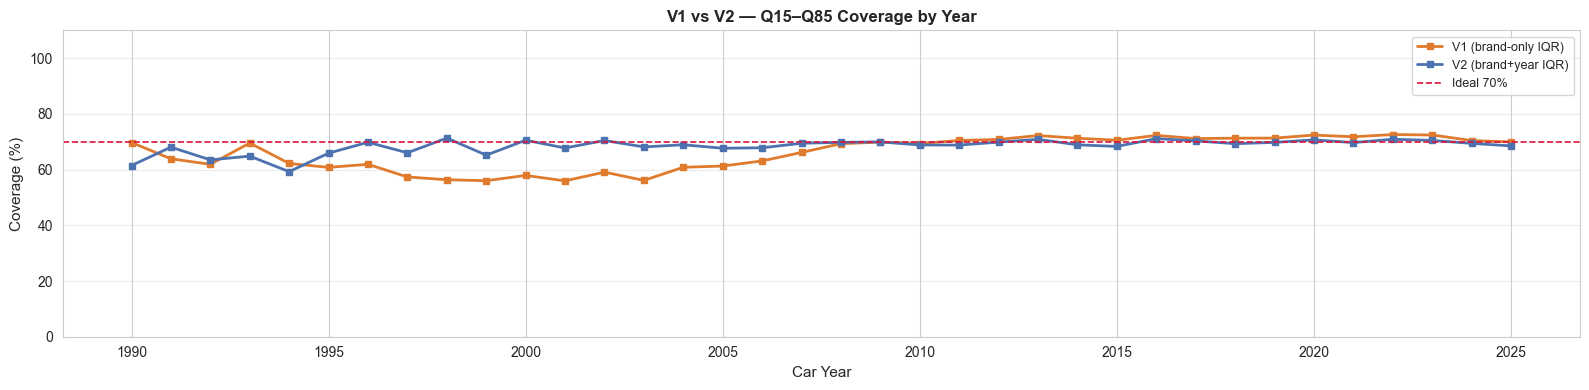

In [14]:
fig, ax = plt.subplots(figsize=(16, 4))

for ym, color, label in [
    (ym_v1, '#E07B2E', 'V1 (brand-only IQR)'),
    (ym_v2, '#4C72B0', 'V2 (brand+year IQR)'),
]:
    ax.plot(ym['year'], ym['coverage_70'] * 100, marker='s', linewidth=2,
            color=color, markersize=5, label=label)

ax.axhline(70, color='crimson', linestyle='--', linewidth=1.2, label='Ideal 70%')
ax.set_ylim(0, 110)
ax.set_xlabel('Car Year', fontsize=11)
ax.set_ylabel('Coverage (%)', fontsize=11)
ax.set_title('V1 vs V2 — Q15–Q85 Coverage by Year', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

## 11. Save V2 Lean Models

In [ ]:
v2_dir.mkdir(parents=True, exist_ok=True)

for label, m in models_v2.items():
    path = v2_dir / f'lgb_{label}_lean.pkl'
    joblib.dump(m, path)
    print(f'  Saved {path.name}')

joblib.dump(fe_v2, v2_dir / 'feature_engineer_lean.pkl')
print('  Saved feature_engineer_lean.pkl')

(v2_dir / 'feature_list.txt').write_text('\n'.join(LEAN_FEATURES))
print('  Saved feature_list.txt')

(v2_dir / 'brand_list.txt').write_text('\n'.join(sorted(fe_v2.brand_price_stats_.keys())))
print('  Saved brand_list.txt')

metadata_v2 = {
    'training_date':    datetime.now().isoformat(),
    'variant':          'lean_v2_brand_year_iqr_lean_features',
    'n_samples':        len(df_v2),
    'n_features':       len(LEAN_FEATURES),
    'cleaning': {
        'method':               'brand+year IQR',
        'large_group_threshold': 50,
        'min_group_size':        10,
    },
    'lgb_params':       LGB_PARAMS,
    'evaluation': {
        'test_set':         'December 2025 extraction (genuinely held-out)',
        'n_test':           len(y_dec_eur),
        'mae_q50_eur':      round(float(mae_v2), 2),
        'coverage_q15_q85': round(float(cov_v2), 2),
    },
    'features': {
        'all_features': LEAN_FEATURES,
        'total_brands': len(fe_v2.brand_price_stats_),
        'total_models': len(fe_v2.model_price_stats_),
    },
    'comparison_note': 'Identical features and hyperparams to V1. Only cleaning differs.',
}

with open(v2_dir / 'metadata.json', 'w') as f:
    json.dump(metadata_v2, f, indent=2)
print('  Saved metadata.json')

print(f'\n\u2713 All V2 artifacts saved to {v2_dir}')

## 12. MLflow Logging

In [ ]:
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment('car_price_lean_cleaning_comparison')

for variant_label, preds_log, preds_eur_dict, n_train in [
    ('v1_brand_iqr',      preds_v1_log, preds_v1_eur, meta_v1['n_samples']),
    ('v2_brand_year_iqr', preds_v2_log, preds_v2_eur, len(df_v2)),
]:
    with mlflow.start_run(run_name=variant_label):
        mlflow.log_params({
            'variant':          variant_label,
            'n_train':          n_train,
            'n_test':           len(y_dec_eur),
            'test_set':         'december_2025',
            'n_features':       len(LEAN_FEATURES),
            'lgb_lr':           LGB_PARAMS['learning_rate'],
            'lgb_n_estimators': LGB_PARAMS['n_estimators'],
        })
        for alpha, label in [(0.15, 'q15'), (0.50, 'q50'), (0.85, 'q85')]:
            pl_val = pinball_loss(np.log(np.clip(y_dec_eur, 1e-6, None)), preds_log[label], alpha)
            mlflow.log_metric(f'pinball_{label}', round(pl_val, 5))
            medape = float(np.median(np.abs(y_dec_eur - preds_eur_dict[label]) / np.clip(y_dec_eur, 1, None) * 100))
            mlflow.log_metric(f'median_ape_{label}', round(medape, 3))
        cov = float(np.mean((preds_eur_dict['q15'] <= y_dec_eur) & (y_dec_eur <= preds_eur_dict['q85'])))
        mlflow.log_metric('coverage_q15_q85', round(cov, 4))
        mlflow.log_metric('mae_q50_eur', round(mean_absolute_error(y_dec_eur, preds_eur_dict['q50']), 2))
        print(f'  \u2713 Logged {variant_label}')

print(f'\nMLflow experiment : car_price_lean_cleaning_comparison')
print(f'Location          : {MLFLOW_URI}')
print(f'(View with: mlflow ui --backend-store-uri {MLFLOW_URI} --port 5001)')

## 13. Summary

In [ ]:
wm_v1 = (ym_v1['median_ape'] * ym_v1['n']).sum() / ym_v1['n'].sum()
wm_v2 = (ym_v2['median_ape'] * ym_v2['n']).sum() / ym_v2['n'].sum()

delta_mae    = mae_v2 - mae_v1
delta_medape = wm_v2 - wm_v1
delta_cov    = cov_v2 - cov_v1

print('=' * 65)
print('SUMMARY \u2014 V1 vs V2 Cleaning Comparison')
print('=' * 65)
print(f'Test set : {len(y_dec_eur):,} December 2025 cars (genuinely held-out)')
print()
print(f'                       V1            V2        Delta')
print(f'  MAE q50 (\u20ac)       : {mae_v1:>9,.0f}    {mae_v2:>9,.0f}    {delta_mae:>+9,.0f}')
print(f'  Median APE wm (%) : {wm_v1:>9.2f}    {wm_v2:>9.2f}    {delta_medape:>+9.2f}')
print(f'  Q15-Q85 coverage  : {cov_v1:>9.1f}%   {cov_v2:>9.1f}%   {delta_cov:>+8.1f}pp')
print()
print('Features   : lean spec (31 cols \u2014 brand/model/year stats only)')
print('Hyperparams: lr=0.1, n=5000 (identical for both)')
print('V1 trained : NB06, 100% of V1-cleaned October data (brand-only IQR)')
print('V2 trained : 100% of V2-cleaned October data (brand+year IQR)')
print('Test set   : December 2025 extraction (neither model trained on it)')
print(f'V2 saved to: {v2_dir}')
print()
print('Interpretation guide:')
print('  MAE / Median APE lower  \u2192 better overall accuracy')
print('  Pre-2005 bucket lower   \u2192 age bias reduced by new cleaning')
print('  Coverage closer to 70%  \u2192 better calibrated intervals')
print('\n\u2713 Notebook complete')